911 Exploratory Analysis Project

## Ingest

For this project we'll analyze the 911 call dataset from [Kaggle](https://www.kaggle.com/mchirico/montcoalert). 


The data contains the following fields:

* lat : String, Latitude
* lng: String, Longitude
* desc: String, Description of the Emergency Call
* zip: String, Zipcode
* title: String, Title
* timeStamp: String, YYYY-MM-DD HH:MM:SS
* twp: String, Township
* addr: String, Address
* e: String, Dummy variable (always 1)

Let's start with some data analysis and visualisation imports.

In [2]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (6, 4)

In [4]:
#Reading the data
df = pd.read_csv('../data/911.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


In [6]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [7]:
df.tail()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
99487,40.132869,-75.333515,MARKLEY ST & W LOGAN ST; NORRISTOWN; 2016-08-2...,19401.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:06:00,NORRISTOWN,MARKLEY ST & W LOGAN ST,1
99488,40.006974,-75.289080,LANCASTER AVE & RITTENHOUSE PL; LOWER MERION; ...,19003.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:07:02,LOWER MERION,LANCASTER AVE & RITTENHOUSE PL,1
99489,40.115429,-75.334679,CHESTNUT ST & WALNUT ST; NORRISTOWN; Station ...,19401.0,EMS: FALL VICTIM,2016-08-24 11:12:00,NORRISTOWN,CHESTNUT ST & WALNUT ST,1
99490,40.186431,-75.192555,WELSH RD & WEBSTER LN; HORSHAM; Station 352; ...,19002.0,EMS: NAUSEA/VOMITING,2016-08-24 11:17:01,HORSHAM,WELSH RD & WEBSTER LN,1
99491,40.207055,-75.317952,MORRIS RD & S BROAD ST; UPPER GWYNEDD; 2016-08...,19446.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:17:02,UPPER GWYNEDD,MORRIS RD & S BROAD ST,1


In [8]:
df.columns

Index(['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e'], dtype='object')

In [9]:
df.shape

(99492, 9)

## EDA

### Basic Analysis

Let's check out the top 5 zipcodes for calls.

In [10]:
df['zip'].value_counts().head(5)

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

The top townships for the calls were as follows:

In [11]:
df['twp'].value_counts().head(5)

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

For 90k + entries, how many unique call titles did we have? 

In [12]:
df['title'].nunique()

110

### Data Wrangling for Feature Creation

We can extract some generalised features from the columns in our dataset for further analysis. 

In the _title_ column, there's a kind of 'subcategory' or 'reason for call' alloted to each entry (denoted by the text before the colon). 

The timestamp column can be further segregated into Year, Month and Day of Week too. 

Let's start with creating a 'Reason' feature for each call.

In [13]:
df['Reason'] = df['title'].apply(lambda x: x.split(':')[0])

In [14]:
df.tail()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason
99487,40.132869,-75.333515,MARKLEY ST & W LOGAN ST; NORRISTOWN; 2016-08-2...,19401.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:06:00,NORRISTOWN,MARKLEY ST & W LOGAN ST,1,Traffic
99488,40.006974,-75.289080,LANCASTER AVE & RITTENHOUSE PL; LOWER MERION; ...,19003.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:07:02,LOWER MERION,LANCASTER AVE & RITTENHOUSE PL,1,Traffic
99489,40.115429,-75.334679,CHESTNUT ST & WALNUT ST; NORRISTOWN; Station ...,19401.0,EMS: FALL VICTIM,2016-08-24 11:12:00,NORRISTOWN,CHESTNUT ST & WALNUT ST,1,EMS
99490,40.186431,-75.192555,WELSH RD & WEBSTER LN; HORSHAM; Station 352; ...,19002.0,EMS: NAUSEA/VOMITING,2016-08-24 11:17:01,HORSHAM,WELSH RD & WEBSTER LN,1,EMS
99491,40.207055,-75.317952,MORRIS RD & S BROAD ST; UPPER GWYNEDD; 2016-08...,19446.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:17:02,UPPER GWYNEDD,MORRIS RD & S BROAD ST,1,Traffic


Now, let's find out the most common reason for 911 calls, according to our dataset.

In [15]:
df['Reason'].value_counts()

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Reason'>

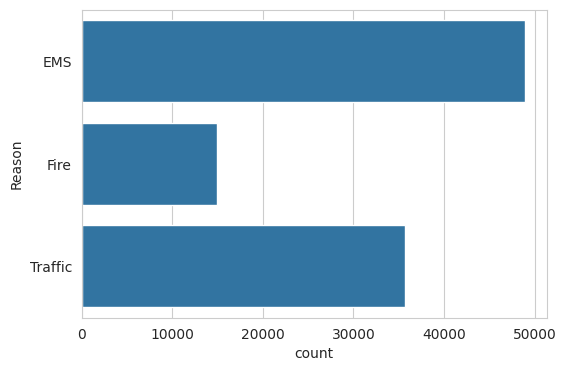

In [16]:
sns.countplot(df['Reason'])

Let's deal with the time information we have. Checking the datatype of the timestamp column.

In [17]:
type(df['timeStamp'][0])

str

As the timestamps are still string types, it'll make our life easier if we convert it to a python DateTime object, so we can extract the year, month, and day information more intuitively. 

In [18]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

For a single DateTime object, we can extract information as follows.

In [19]:
time = df['timeStamp'].iloc[0]

print('Hour:',time.hour)
print('Month:',time.month)
print('Day of Week:',time.dayofweek)

Hour: 17
Month: 12
Day of Week: 3


Now let's create new features for the above pieces of information.

In [20]:
df['Hour'] = df['timeStamp'].apply(lambda x: x.hour)
df['Month'] = df['timeStamp'].apply(lambda x: x.month)
df['Day of Week'] = df['timeStamp'].apply(lambda x: x.dayofweek)

In [21]:
df.head(3)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day of Week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,3
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,3
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,17,12,3


The Day of the Week is an integer and it might not be instantly clear which number refers to which Day. We can map that information to a Mon-Sun string.

In [22]:
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [23]:
df['Day of Week'] = df['Day of Week'].map(dmap)

df.tail(3)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day of Week
99489,40.115429,-75.334679,CHESTNUT ST & WALNUT ST; NORRISTOWN; Station ...,19401.0,EMS: FALL VICTIM,2016-08-24 11:12:00,NORRISTOWN,CHESTNUT ST & WALNUT ST,1,EMS,11,8,Wed
99490,40.186431,-75.192555,WELSH RD & WEBSTER LN; HORSHAM; Station 352; ...,19002.0,EMS: NAUSEA/VOMITING,2016-08-24 11:17:01,HORSHAM,WELSH RD & WEBSTER LN,1,EMS,11,8,Wed
99491,40.207055,-75.317952,MORRIS RD & S BROAD ST; UPPER GWYNEDD; 2016-08...,19446.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:17:02,UPPER GWYNEDD,MORRIS RD & S BROAD ST,1,Traffic,11,8,Wed


Let's combine the newly created features, to check out the most common call reasons based on the day of the week.

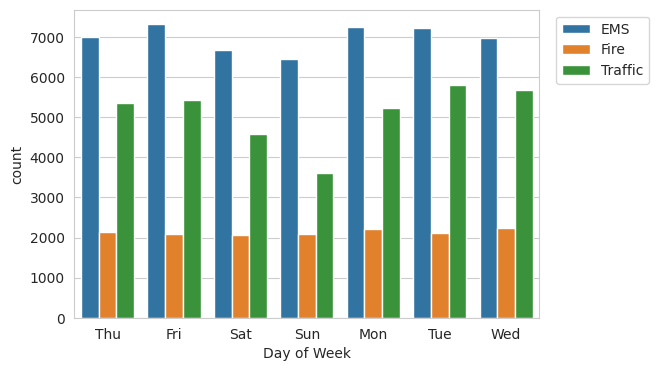

In [25]:
sns.countplot(x='Day of Week', hue='Reason', data=df)

plt.legend(bbox_to_anchor=(1.25,1))

It makes sense for the number of traffic related 911 calls to be the lowest during the weekends, what's also iteresting is that Emergency Service related calls are also low during the weekend.

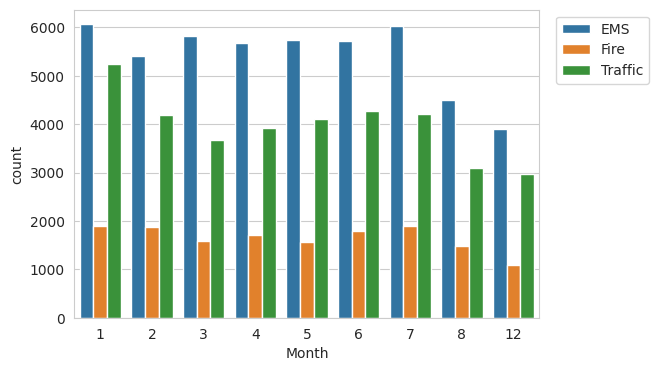

In [26]:
sns.countplot(x=df['Month'],hue=df['Reason'])

plt.legend(bbox_to_anchor=(1.25,1))

Now, let's check out the relationship between the number of calls and the month.

In [27]:
byMonth = df.groupby(by='Month').count()

Text(0, 0.5, 'Number of Calls')

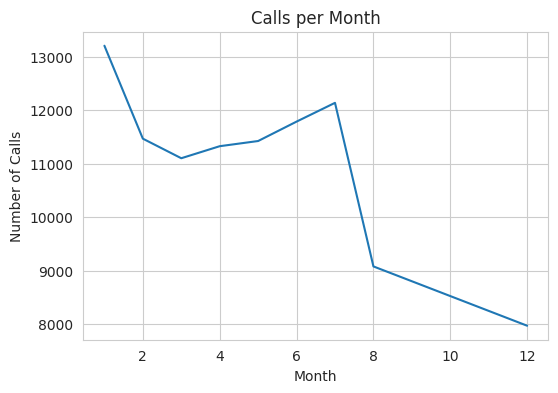

In [28]:
byMonth['e'].plot.line(y='e')
plt.title('Calls per Month')
plt.ylabel('Number of Calls')

Using seaborn, let's fit the number of calls to a month and see if there's any concrete correlation between the two.

In [29]:
byMonth.reset_index(inplace=True)

Text(7.000000000000009, 0.5, 'Number of Calls')

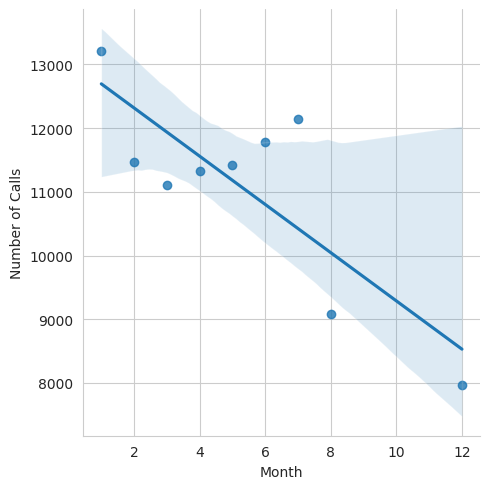

In [30]:
sns.lmplot(x='Month',y='e',data=byMonth)
plt.ylabel('Number of Calls')

So, it does seem that there are fewer emergency calls during the holiday seasons.

Let's extract the date from the timestamp, and see behavior in a little more detail.

In [31]:
df['Date']=df['timeStamp'].apply(lambda x: x.date())

In [32]:
df.head(2)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day of Week,Date
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,Thu,2015-12-10
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,Thu,2015-12-10


Grouping and plotting the data: 

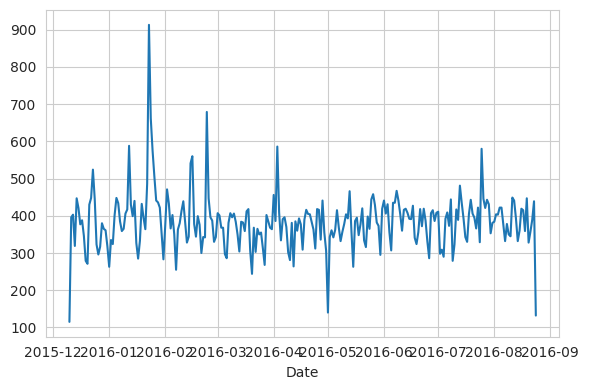

In [34]:
df.groupby('Date').count()['e'].plot.line(y='e')

plt.legend().remove()
plt.tight_layout()

We can also check out the same plot for each reason separately.

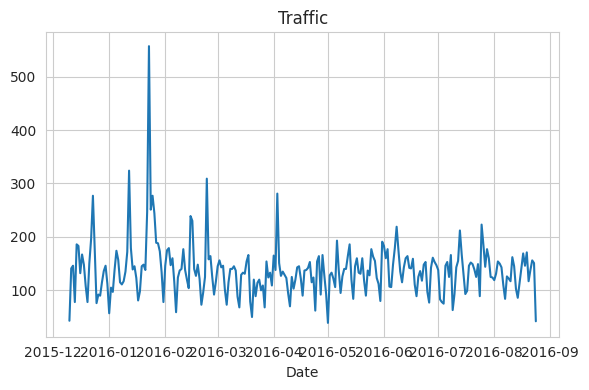

In [35]:
pd.DataFrame.groupby(df[df['Reason']=='Traffic'],'Date').count().plot.line(y='e')
plt.title('Traffic')
plt.legend().remove()
plt.tight_layout()

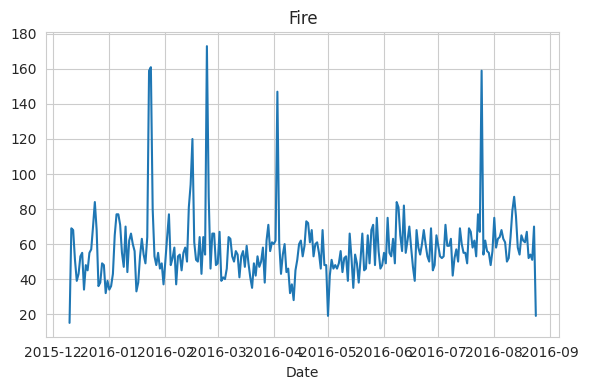

In [36]:
pd.DataFrame.groupby(df[df['Reason']=='Fire'],'Date').count().plot.line(y='e')
plt.title('Fire')
plt.legend().remove()
plt.tight_layout()

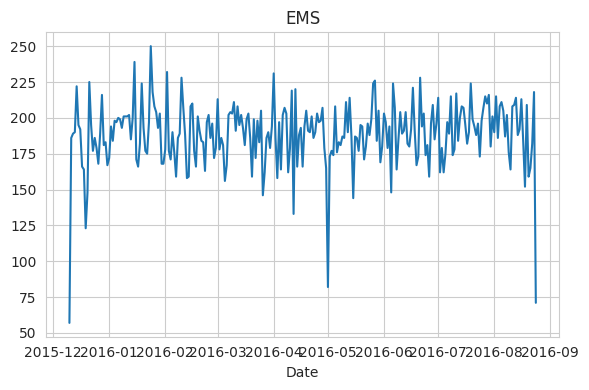

In [37]:
pd.DataFrame.groupby(df[df['Reason']=='EMS'],'Date').count().plot.line(y='e')
plt.title('EMS')
plt.legend().remove()
plt.tight_layout()

Let's create a heatmap for the counts of calls on each hour, during a given day of the week.

In [38]:
day_hour = df.pivot_table(values='lat',index='Day of Week',columns='Hour',aggfunc='count')

day_hour

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354
Tue,269,240,186,170,209,239,415,655,889,880,...,943,938,1026,1019,905,731,647,571,462,274
Wed,250,216,189,209,156,255,410,701,875,808,...,904,867,990,1037,894,686,668,575,490,335


** Now create a HeatMap using this new DataFrame. **

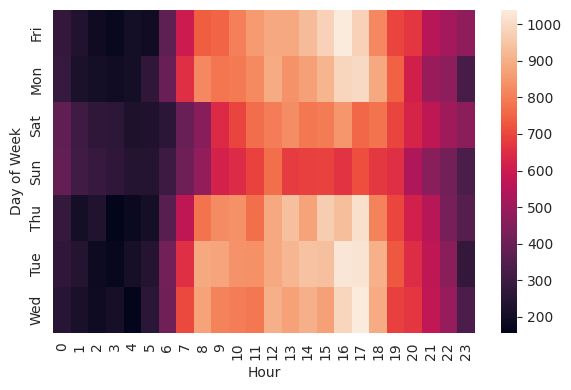

In [39]:
sns.heatmap(day_hour)

plt.tight_layout()

We see that most calls take place around the end of office hours on weekdays. We can create a clustermap to pair up similar Hours and Days.

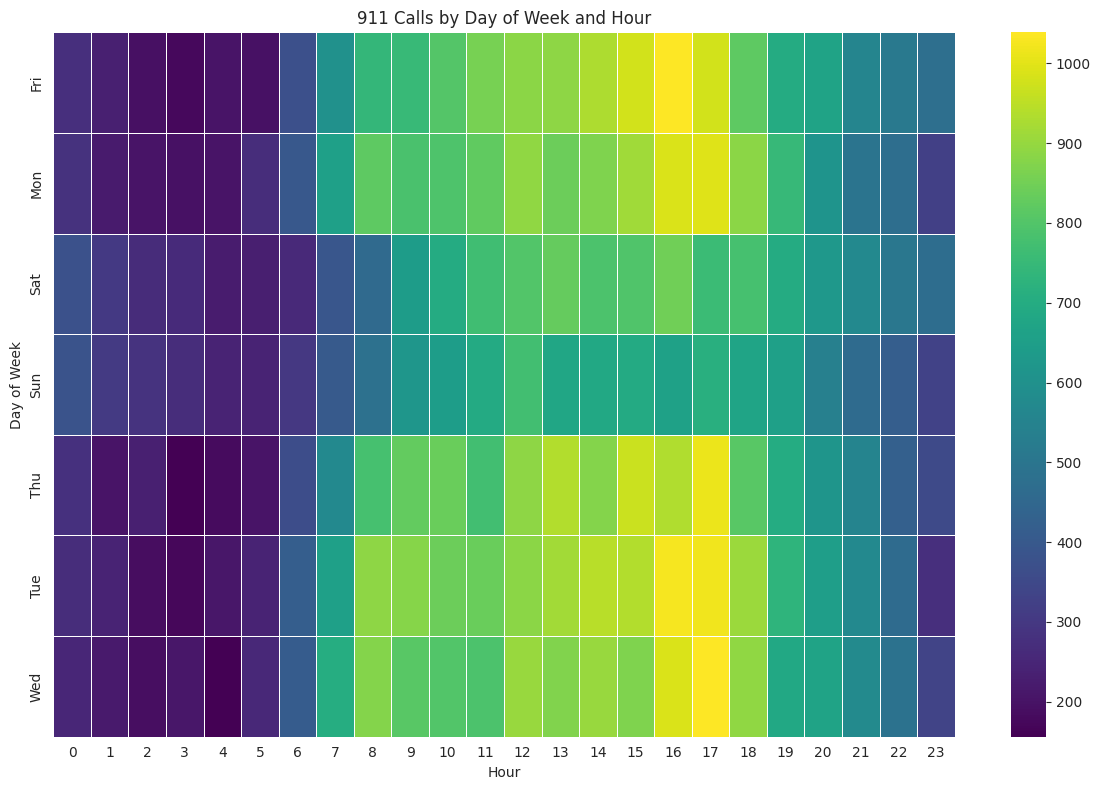

In [44]:
plt.figure(figsize=(12, 8))
sns.heatmap(day_hour, 
            cmap='viridis',
            linewidths=0.5, 
            annot=False)
plt.title('911 Calls by Day of Week and Hour')
plt.tight_layout()


## Conclusion

this notebook is a basic exploratory analysis of the 911 call dataset. We have created new features from the existing columns, and visualised the data using seaborn and matplotlib.
#write a conclusion here

### Key Findings

Through this exploratory analysis of 911 call data, we've identified several significant patterns:

1. **Call Type Distribution**: Emergency Medical Services (EMS) represent the highest volume of emergency calls, followed by Traffic incidents and Fire emergencies.

2. **Temporal Patterns**:
   - Weekday vs Weekend: Call volumes drop significantly during weekends, particularly for traffic-related incidents
   - Monthly Trends: There appears to be a negative correlation between call volume and holiday seasons
   - Daily Patterns: Call volumes peak during evening rush hours (4-6 PM) on weekdays

3. **Geographic Concentration**: Certain townships and zip codes show significantly higher call volumes, suggesting potential hotspots for emergency services.

### Implications

These insights could help emergency service providers with:
- Resource allocation by time of day and week
- Staffing optimization based on temporal patterns
- Targeted prevention efforts in high-volume areas
- Performance benchmarking across different regions

### Limitations

- This analysis is descriptive rather than predictive
- We haven't controlled for population density or other demographic factors
- Weather and seasonal effects could be explored further
- The dataset is limited to one geographic region

### Future Work

To extend this analysis, we could:
1. Incorporate geospatial visualization to map call density by location
2. Develop predictive models to forecast call volumes by time and location
3. Analyze response times in relation to call volumes
4. Perform sentiment analysis on call descriptions to identify emerging trends
5. Integrate with other datasets (weather, traffic, events) to identify correlations

This exploratory analysis serves as a foundation for more advanced analytical approaches to emergency service optimization.
